# HVM T5 Sweep Results
Loads all `checkpoints/transformer/t5/hvm/*/best.pt` and visualises performance across sweep axes.

Target: **T5-XXL PCA projection of the category-name token** (one token per stimulus).
Primary metric: **val cosine similarity** on T5 PCA targets. Secondary: 2-AFC, top-k retrieval.

Sweep axes: `n_layers`, `d_model`, `nce_weight`, `t5_pca_k`. Fixed: `use_category=True`, `uniformity_weight=0.1`.

In [1]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, '..')
from config_const import CHECKPOINT_DIR, CACHE_DIR

SWEEP_AXES = ['n_layers', 'd_model', 'nce_weight', 't5_pca_k']
SWEEP_DIR  = CHECKPOINT_DIR / 'transformer' / 't5' / 'hvm'

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted(SWEEP_DIR.glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_cos_t5' in df.columns

for col in SWEEP_AXES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

SORT_BY = 'val_cos_t5'
show_cols = SWEEP_AXES + ['train_cos_t5', 'train_2afc_t5', 'val_cos_t5', 'val_2afc_t5', 'epoch']
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} runs loaded from {SWEEP_DIR}  |  test metrics present: {has_test}')
print(df[show_cols].sort_values(SORT_BY, ascending=False).to_string(index=False))

Loading:   0%|          | 0/36 [00:00<?, ?it/s]

36 runs loaded from /home/yy3658/NeurObjectGen/checkpoints/transformer/t5/hvm  |  test metrics present: True
 n_layers  d_model  nce_weight  t5_pca_k  train_cos_t5  train_2afc_t5  val_cos_t5  val_2afc_t5  epoch
        4      256         0.1        64      0.993138       0.518587    0.992658     0.473034     42
        2      256         0.1        64      0.992993       0.565799    0.992438     0.492135     44
        4      128         0.1        64      0.992024       0.546097    0.991769     0.513483     44
        2      128         0.1        64      0.991862       0.574721    0.991529     0.515730     44
        4      256         0.5        64      0.987042       0.630112    0.985598     0.519101     21
        2      256         0.5        64      0.986154       0.623420    0.984670     0.516854     21
        4      128         0.5        64      0.983117       0.637546    0.983152     0.551685     28
        2      128         0.5        64      0.983534       0.637175    0.

## Metrics by sweep axis

/tmp/ipykernel_46648/831762734.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pk_cmap  = plt.cm.get_cmap('Set1', max(len(pk_vals), 2))


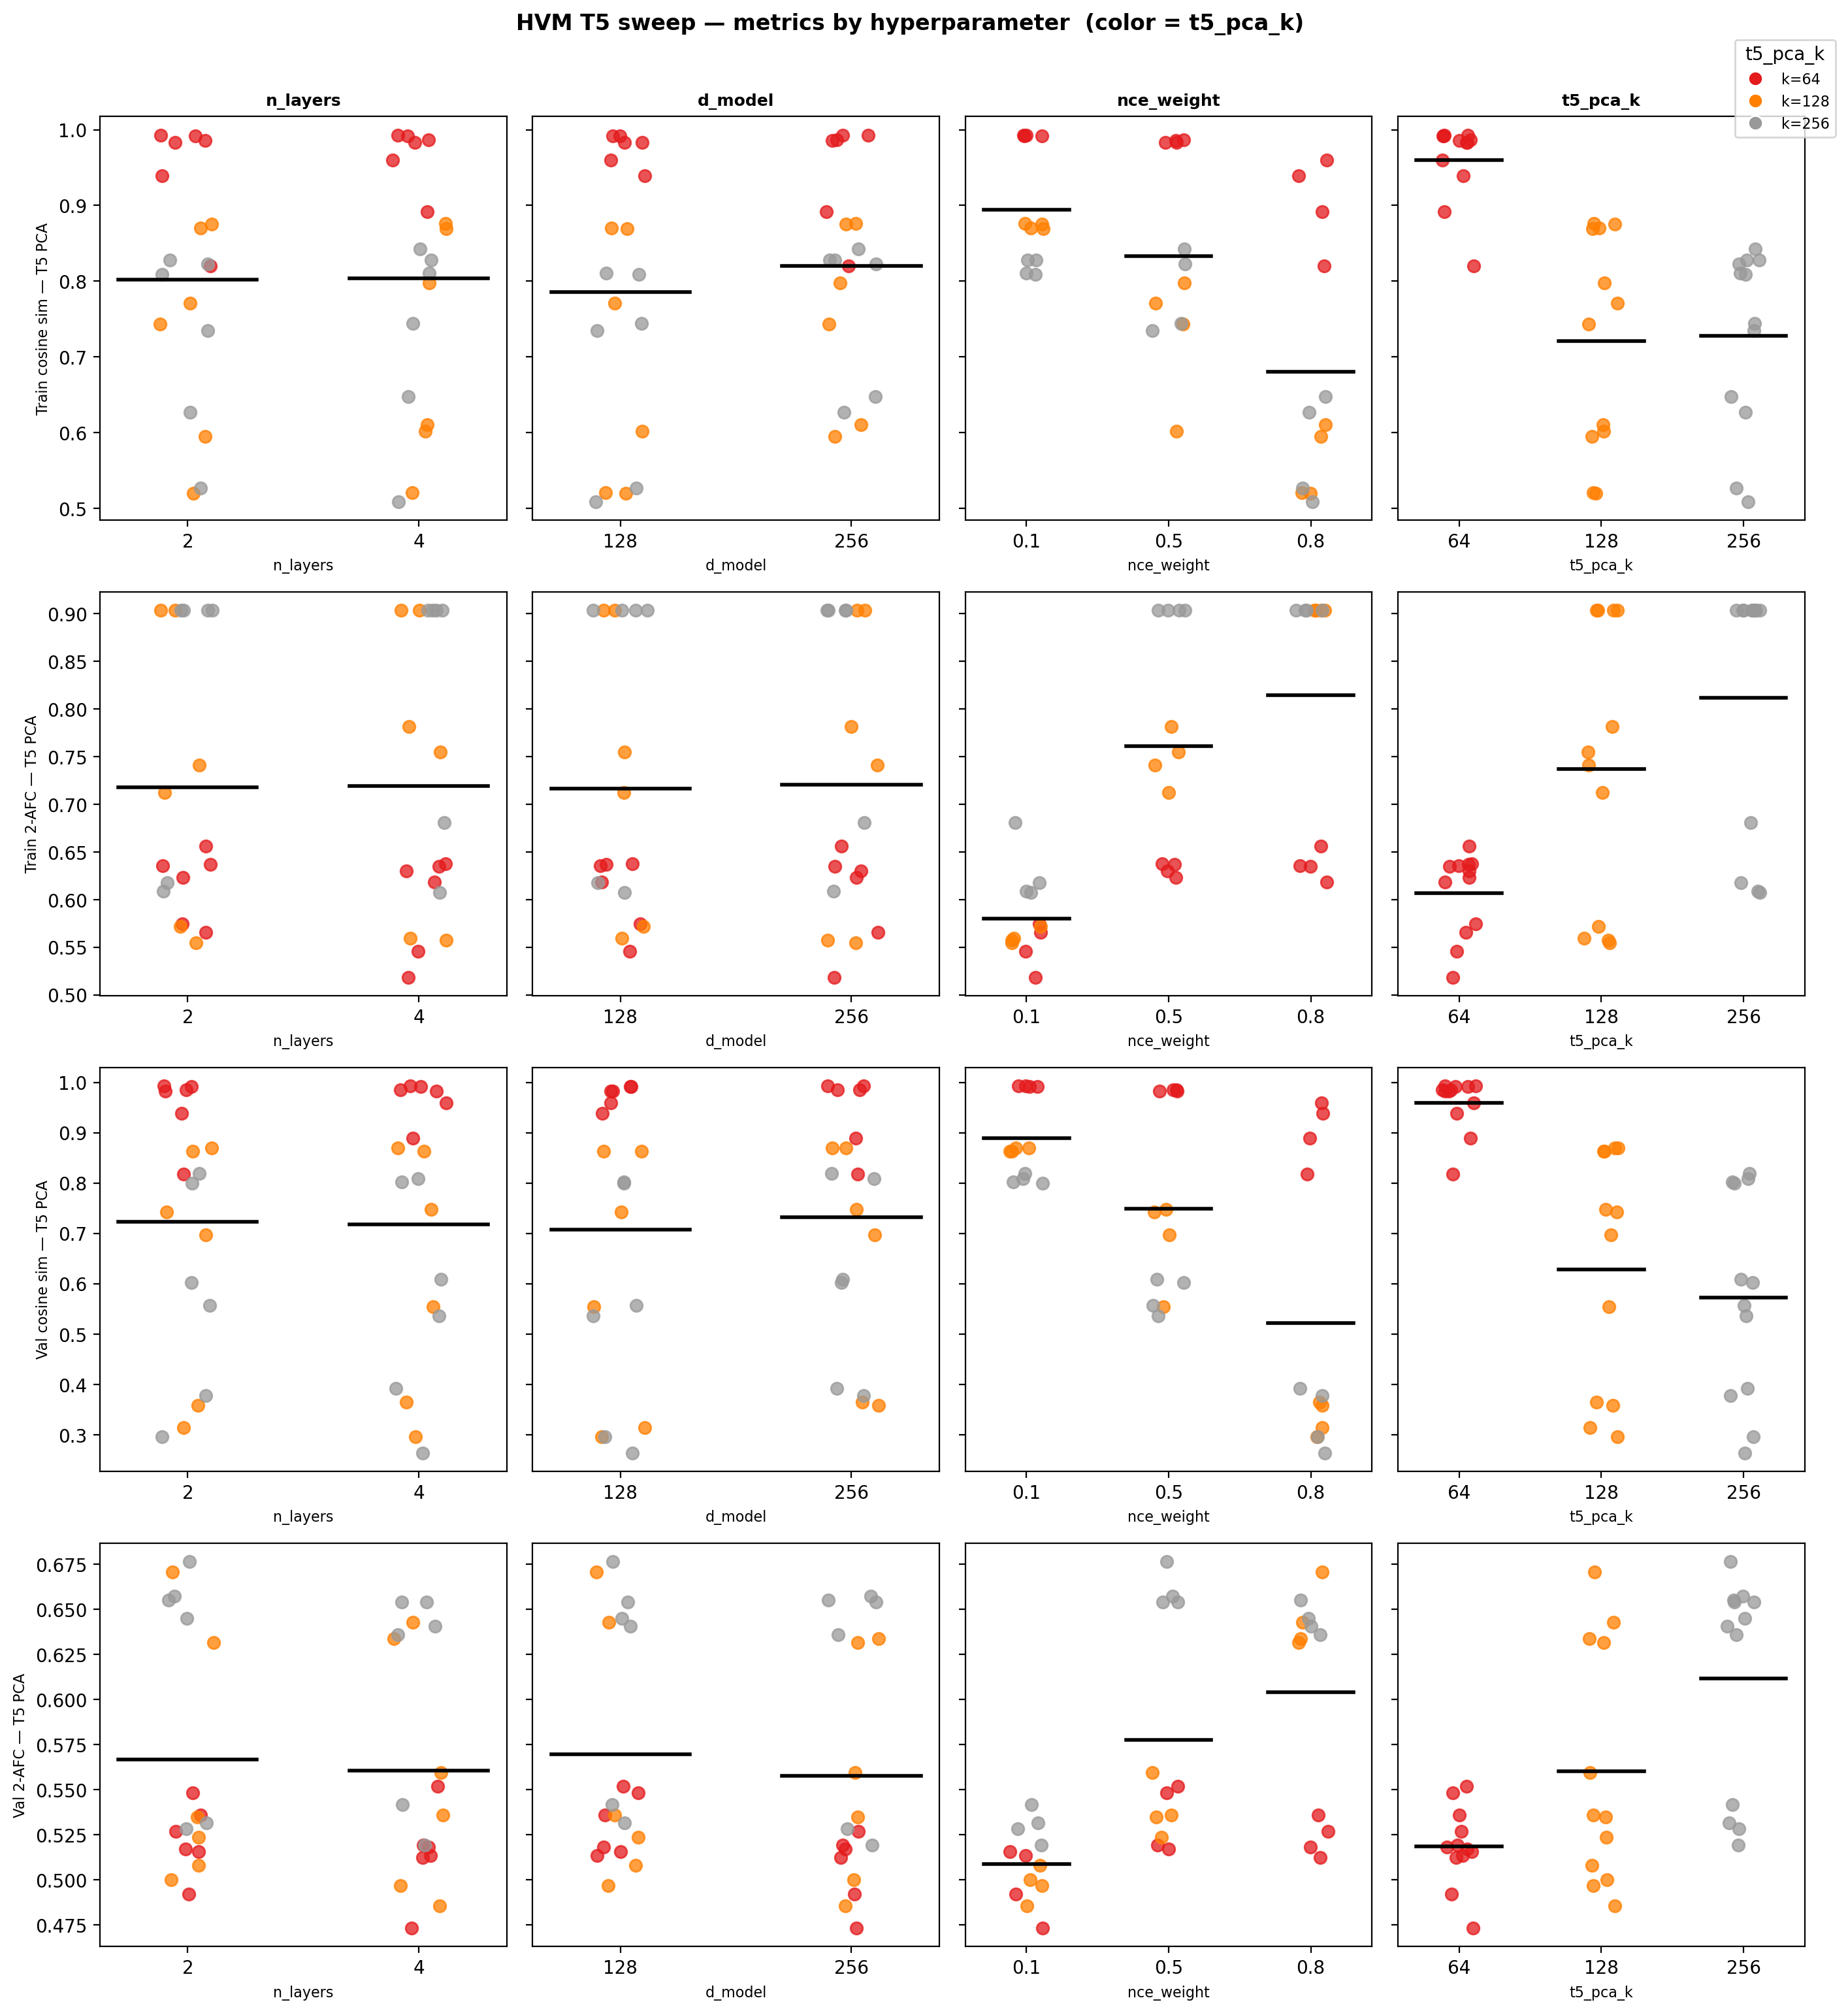

In [2]:
METRICS = [
    ('train_cos_t5',  'Train cosine sim — T5 PCA'),
    ('train_2afc_t5', 'Train 2-AFC — T5 PCA'),
    ('val_cos_t5',    'Val cosine sim — T5 PCA'),
    ('val_2afc_t5',   'Val 2-AFC — T5 PCA'),
]
present_metrics = [(m, l) for m, l in METRICS if m in df.columns]

fig, axes = plt.subplots(len(present_metrics), len(SWEEP_AXES),
                         figsize=(3.5 * len(SWEEP_AXES), 3.8 * len(present_metrics)),
                         sharey='row', squeeze=False)

rng = np.random.default_rng(0)

# Colour by t5_pca_k
pk_vals  = sorted(df['t5_pca_k'].unique()) if 't5_pca_k' in df.columns else []
pk_cmap  = plt.cm.get_cmap('Set1', max(len(pk_vals), 2))
pk_color = {v: pk_cmap(i) for i, v in enumerate(pk_vals)}

for mi, (metric, ylabel) in enumerate(present_metrics):
    for ai, axis_col in enumerate(SWEEP_AXES):
        ax = axes[mi, ai]
        if axis_col not in df.columns:
            ax.axis('off'); continue
        levels = sorted(df[axis_col].unique())
        for lvl_i, lvl in enumerate(levels):
            sub = df[df[axis_col] == lvl]
            for pk, grp in sub.groupby('t5_pca_k'):
                vals = grp[metric].dropna().values
                if not len(vals): continue
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=pk_color[pk], alpha=0.75, s=45,
                           label=f'k={pk}' if ai == 0 and lvl_i == 0 else '_')
            all_vals = sub[metric].dropna().values
            if len(all_vals):
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [all_vals.mean(), all_vals.mean()], 'k-', lw=2)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels])
        ax.set_xlabel(axis_col, fontsize=8)
        if ai == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if mi == 0:
            ax.set_title(axis_col, fontsize=9, fontweight='bold')

handles = [plt.Line2D([0],[0],marker='o',color='w',
           markerfacecolor=pk_color[v],markersize=8,label=f'k={v}') for v in pk_vals]
fig.legend(handles=handles, title='t5_pca_k', loc='upper right',
           bbox_to_anchor=(1.01, 1), fontsize=8)
fig.suptitle('HVM T5 sweep — metrics by hyperparameter  (color = t5_pca_k)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Effect of nce_weight

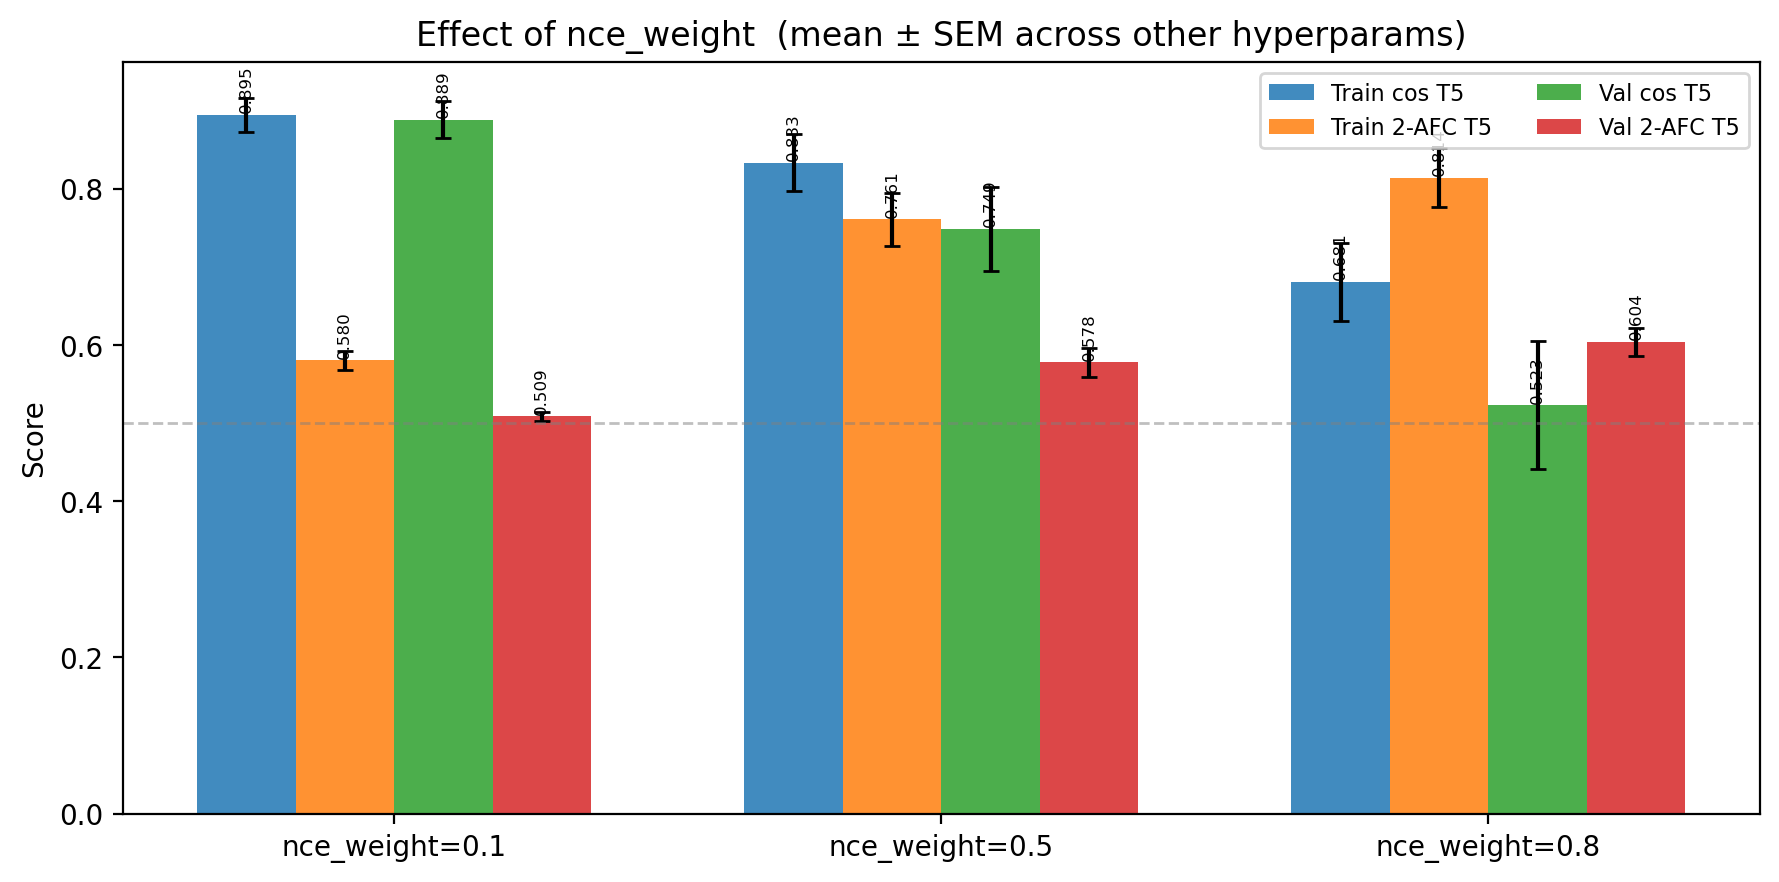

In [3]:
metrics_ab = [
    ('train_cos_t5',  'Train cos T5'),
    ('train_2afc_t5', 'Train 2-AFC T5'),
    ('val_cos_t5',    'Val cos T5'),
    ('val_2afc_t5',   'Val 2-AFC T5'),
]
metrics_ab = [(m, l) for m, l in metrics_ab if m in df.columns]
nw_labels = sorted(df['nce_weight'].unique())
x = np.arange(len(nw_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(9, 4.5))
offsets = np.linspace(-(len(metrics_ab)-1)/2, (len(metrics_ab)-1)/2, len(metrics_ab)) * width

for off, (metric, label) in zip(offsets, metrics_ab):
    means = [df[df['nce_weight'] == w][metric].mean() for w in nw_labels]
    sems  = [df[df['nce_weight'] == w][metric].sem()  for w in nw_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3, label=label, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'nce_weight={v}' for v in nw_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of nce_weight  (mean ± SEM across other hyperparams)')
ax.legend(fontsize=8, ncol=2)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Effect of t5_pca_k

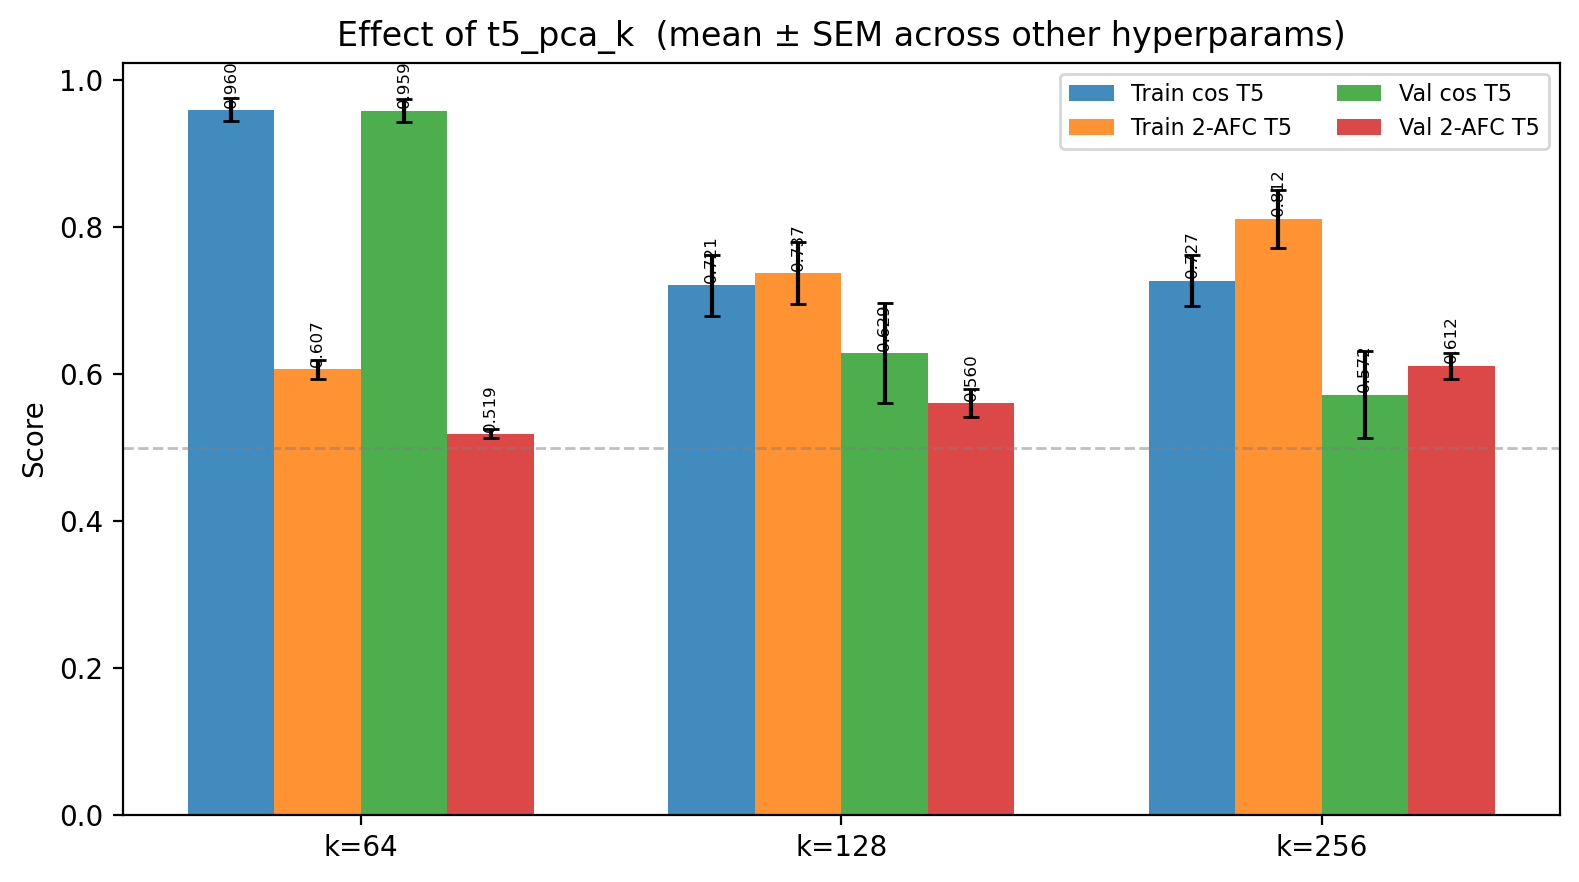

In [4]:
pk_labels = sorted(df['t5_pca_k'].unique()) if 't5_pca_k' in df.columns else []
x = np.arange(len(pk_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 4.5))
offsets = np.linspace(-(len(metrics_ab)-1)/2, (len(metrics_ab)-1)/2, len(metrics_ab)) * width

for off, (metric, label) in zip(offsets, metrics_ab):
    means = [df[df['t5_pca_k'] == k][metric].mean() for k in pk_labels]
    sems  = [df[df['t5_pca_k'] == k][metric].sem()  for k in pk_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3, label=label, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in pk_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of t5_pca_k  (mean ± SEM across other hyperparams)')
ax.legend(fontsize=8, ncol=2)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Train vs val generalisation

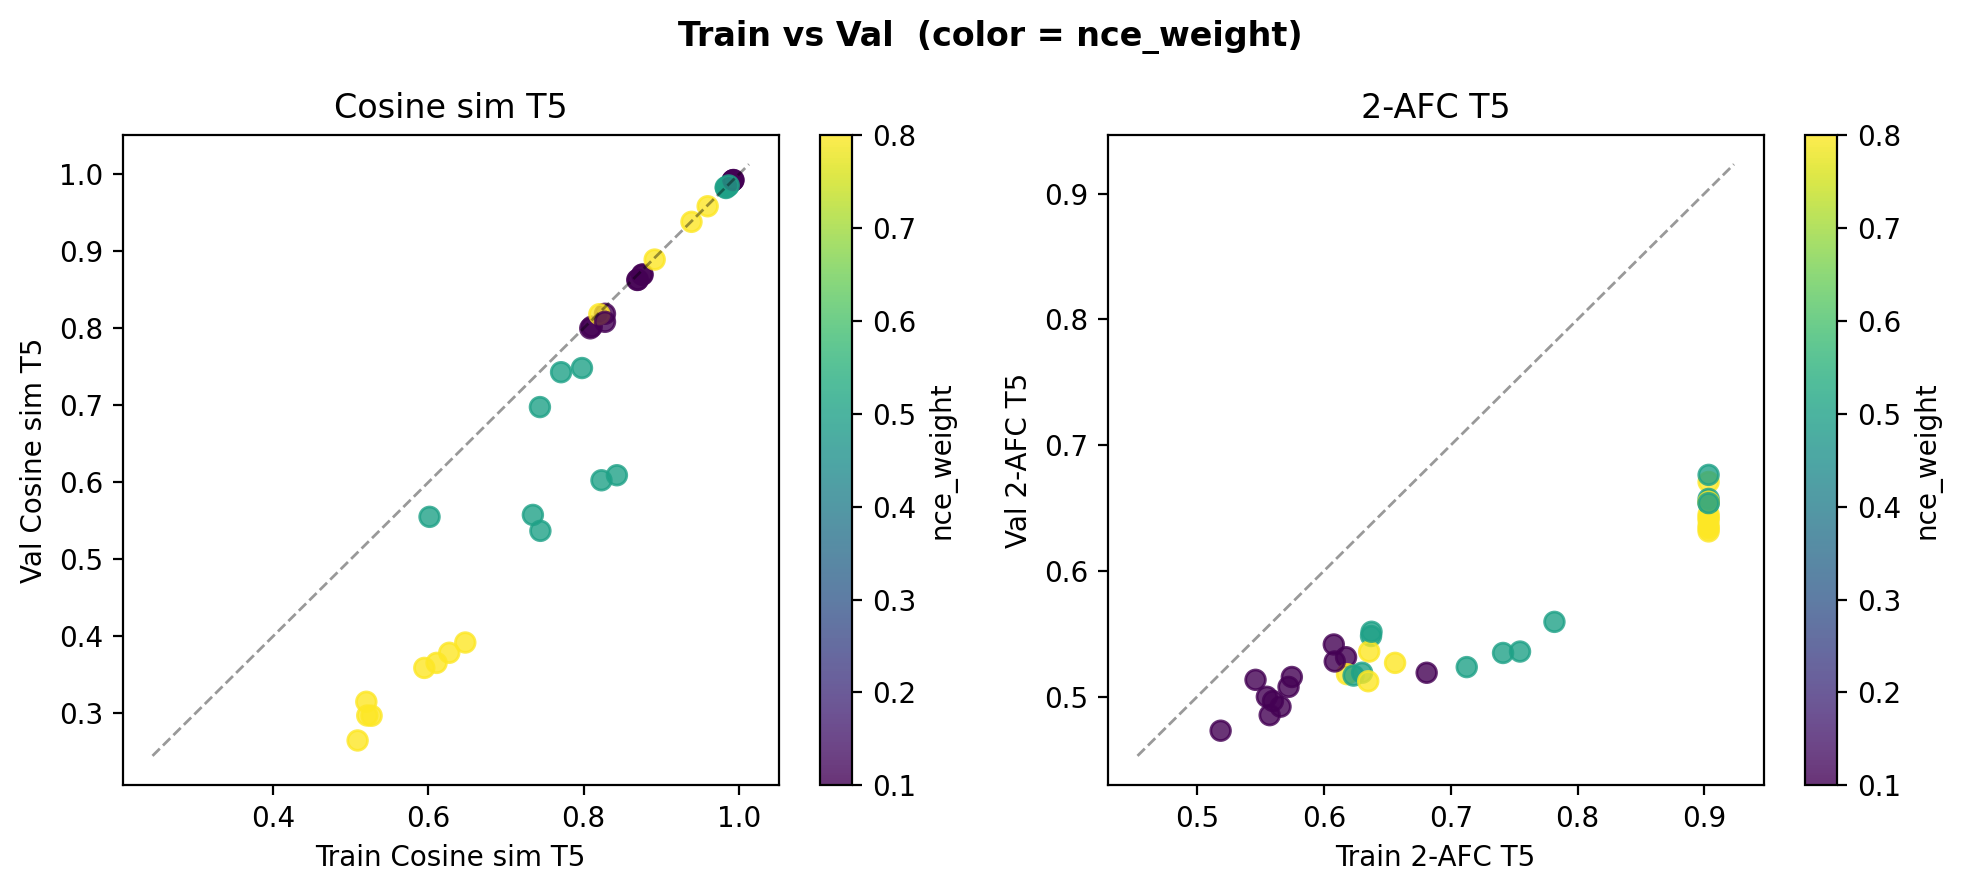

In [5]:
tv_pairs = [
    ('train_cos_t5',  'val_cos_t5',  'Cosine sim T5'),
    ('train_2afc_t5', 'val_2afc_t5', '2-AFC T5'),
]
tv_pairs = [(tc, vc, t) for tc, vc, t in tv_pairs if tc in df.columns and vc in df.columns]

if tv_pairs:
    fig, axes = plt.subplots(1, len(tv_pairs), figsize=(5 * len(tv_pairs), 4.5))
    if len(tv_pairs) == 1:
        axes = [axes]
    for ax, (tcol, vcol, title) in zip(axes, tv_pairs):
        sub = df.dropna(subset=[tcol, vcol])
        sc = ax.scatter(sub[tcol], sub[vcol],
                        c=sub['nce_weight'], cmap='viridis', s=50, alpha=0.8)
        lim = [min(sub[tcol].min(), sub[vcol].min()) - 0.02,
               max(sub[tcol].max(), sub[vcol].max()) + 0.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Train {title}')
        ax.set_ylabel(f'Val {title}')
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='nce_weight')
    fig.suptitle('Train vs Val  (color = nce_weight)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Train metrics not yet available — rerun once jobs complete.')

## Val vs test generalisation

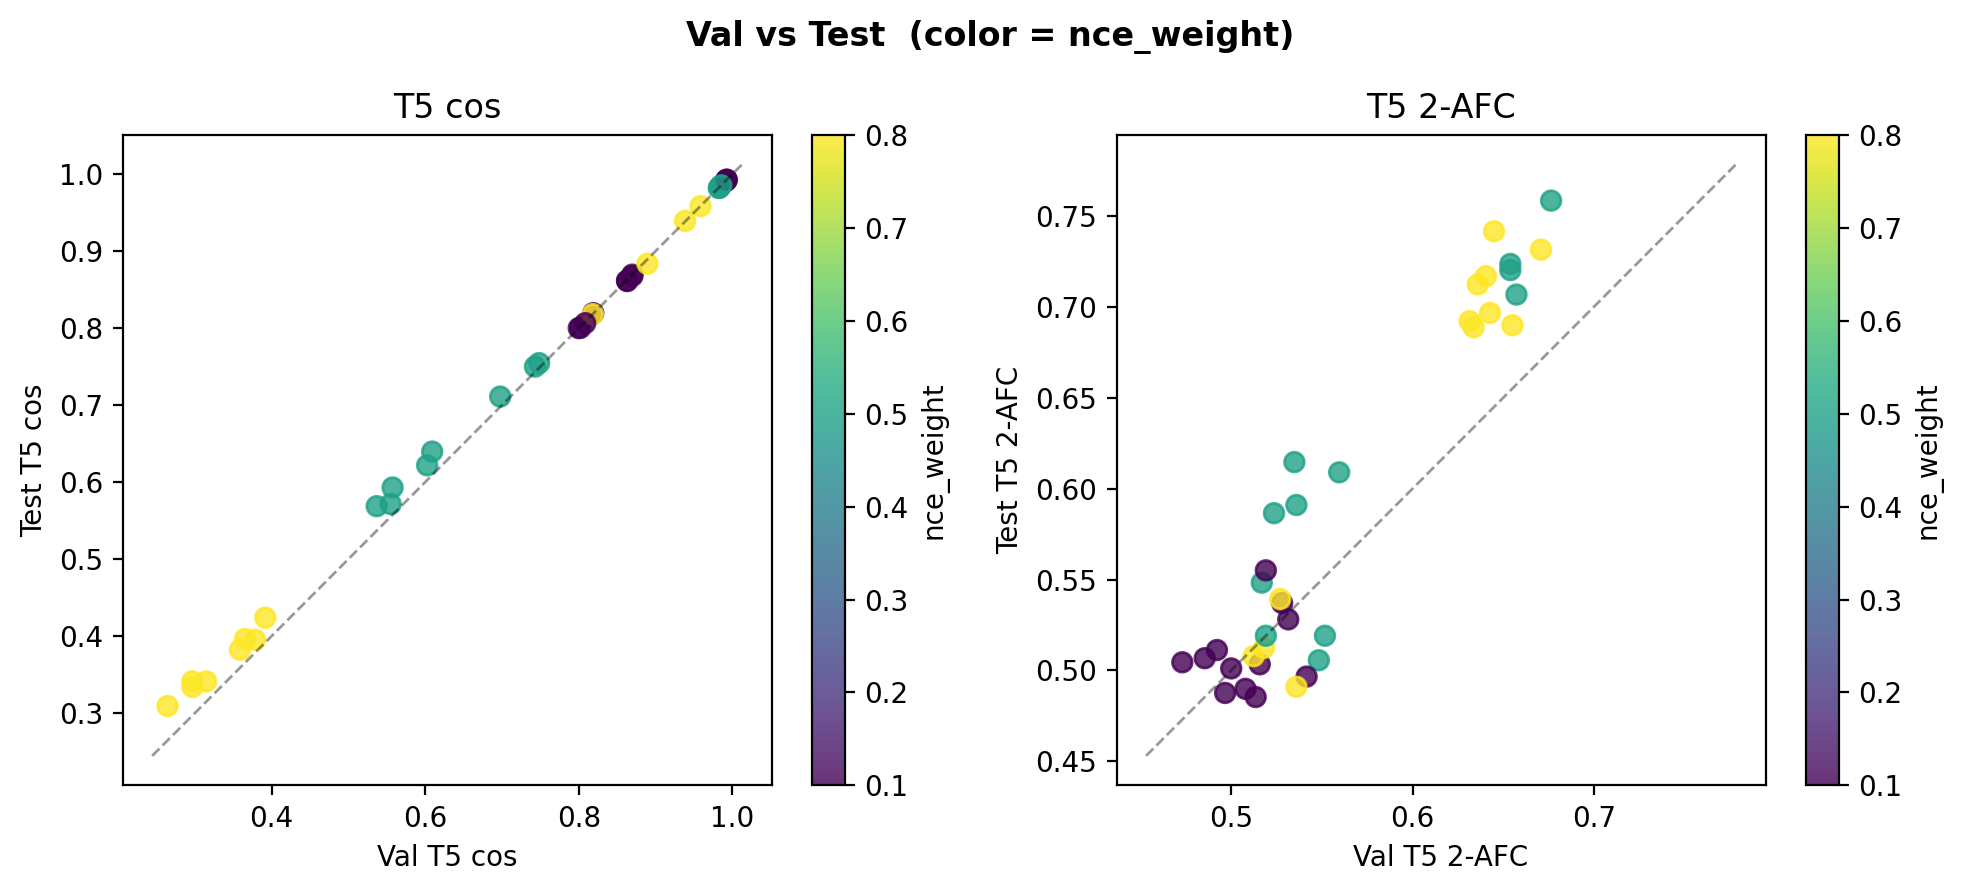

In [6]:
if has_test:
    pairs = [
        ('val_cos_t5',  'test_cos_t5',  'T5 cos'),
        ('val_2afc_t5', 'test_2afc_t5', 'T5 2-AFC'),
    ]
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        sub = df.dropna(subset=[vcol, tcol])
        sc = ax.scatter(sub[vcol], sub[tcol],
                        c=sub['nce_weight'], cmap='viridis', s=50, alpha=0.8)
        lim = [min(sub[vcol].min(), sub[tcol].min()) - 0.02,
               max(sub[vcol].max(), sub[tcol].max()) + 0.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Val {title}')
        ax.set_ylabel(f'Test {title}')
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='nce_weight')
    fig.suptitle('Val vs Test  (color = nce_weight)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Test metrics not yet available — rerun once all jobs complete.')

## Top-10 runs

In [7]:
top_cols = [c for c in
    ['n_layers', 'd_model', 'nce_weight', 't5_pca_k',
     'epoch', 'train_cos_t5', 'train_2afc_t5', 'val_cos_t5', 'val_2afc_t5',
     'test_cos_t5', 'test_2afc_t5', 'test_top1', 'test_top5', 'test_top10', 'path']
    if c in df.columns]
display(df.sort_values('val_cos_t5', ascending=False)[top_cols].head(10).reset_index(drop=True))

,n_layers,d_model,nce_weight,t5_pca_k,epoch,train_cos_t5,train_2afc_t5,val_cos_t5,val_2afc_t5,test_cos_t5,test_2afc_t5,test_top1,test_top5,test_top10,path
0,4,256,0.1,64,42,0.993138,0.518587,0.992658,0.473034,0.992772,0.504494,0.000000,0.055556,0.144444,/home/yy3658/NeurObjectGen/checkpoints/transfo...
1,2,256,0.1,64,44,0.992993,0.565799,0.992438,0.492135,0.992426,0.511236,0.000000,0.055556,0.144444,/home/yy3658/NeurObjectGen/checkpoints/transfo...
2,4,128,0.1,64,44,0.992024,0.546097,0.991769,0.513483,0.991588,0.485393,0.022222,0.088889,0.122222,/home/yy3658/NeurObjectGen/checkpoints/transfo...
3,2,128,0.1,64,44,0.991862,0.574721,0.991529,0.515730,0.991260,0.503371,0.011111,0.077778,0.111111,/home/yy3658/NeurObjectGen/checkpoints/transfo...
4,4,256,0.5,64,21,0.987042,0.630112,0.985598,0.519101,0.985429,0.519101,0.022222,0.144444,0.200000,/home/yy3658/NeurObjectGen/checkpoints/transfo...
5,2,256,0.5,64,21,0.986154,0.623420,0.984670,0.516854,0.984572,0.548315,0.000000,0.144444,0.211111,/home/yy3658/NeurObjectGen/checkpoints/transfo...
6,4,128,0.5,64,28,0.983117,0.637546,0.983152,0.551685,0.982224,0.519101,0.000000,0.066667,0.144444,/home/yy3658/NeurObjectGen/checkpoints/transfo...
7,2,128,0.5,64,28,0.983534,0.637175,0.982272,0.548315,0.982058,0.505618,0.000000,0.077778,0.122222,/home/yy3658/NeurObjectGen/checkpoints/transfo...
8,4,128,0.8,64,30,0.959897,0.618216,0.958558,0.517978,0.958352,0.512360,0.000000,0.111111,0.133333,/home/yy3658/NeurObjectGen/checkpoints/transfo...
9,2,128,0.8,64,21,0.939068,0.635688,0.938326,0.535955,0.939157,0.491011,0.000000,0.044444,0.088889,/home/yy3658/NeurObjectGen/checkpoints/transfo...


## Save best HVM T5 config

In [11]:
import json

best_row = df[df['t5_pca_k'] == 256].sort_values('val_cos_t5', ascending=False).iloc[0]
config = {
    'model':        'transformer_t5',
    'dataset':      'hvm',
    'use_category': True,
    'val_cos_t5':   float(best_row['val_cos_t5']),
    'val_2afc_t5':  float(best_row['val_2afc_t5'])  if 'val_2afc_t5'  in best_row else None,
    'train_cos_t5': float(best_row['train_cos_t5']) if 'train_cos_t5' in best_row else None,
    'checkpoint':   best_row['path'],
    'd_model':      int(best_row['d_model']),
    'n_heads':      int(best_row['n_heads']),
    'n_layers':     int(best_row['n_layers']),
    't5_pca_k':     int(best_row['t5_pca_k']),
    'dropout':      float(best_row['dropout']),
    'nce_weight':        float(best_row['nce_weight']),
    'nce_temperature':   float(best_row['nce_temperature']),
    'uniformity_weight': float(best_row['uniformity_weight']),
    'lr':           float(best_row['lr']),
    'weight_decay': float(best_row['weight_decay']),
}

out_path = CACHE_DIR / 'best_hvm_t5_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {out_path}')
print(f"  val_cos_t5={config['val_cos_t5']:.4f}")
if config['val_2afc_t5']:
    print(f"  val_2afc_t5={config['val_2afc_t5']:.3f}")
if config['train_cos_t5']:
    print(f"  train_cos_t5={config['train_cos_t5']:.4f}")
print(f"  {config['checkpoint']}")

Saved to /home/yy3658/NeurObjectGen/cache/best_hvm_t5_config.json
  val_cos_t5=0.8188
  val_2afc_t5=0.528
  train_cos_t5=0.8275
  /home/yy3658/NeurObjectGen/checkpoints/transformer/t5/hvm/d256_nh4_nl2_k256_do0.1_lr0.0003_wd0.01_tn0.0_in0.05_nd0.1_bs256_nw0.1_nt0.07_uw0.1_cat/best.pt
